0317(월) 3주차 과제\
핸즈온 9장 비지도학습 p.299-328

In [1]:
# 데이터 불러오기

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

In [2]:
# 추가 코드 - make_blobs()의 정확한 인수는 중요하지 않습니다.

blob_centers = np.array([[ 0.2, 2.3], [-1.5 , 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

**이 장에서 배울 내용**
- 비지도학습, 알고리즘 등
- 군집
 - 비슷한 샘플을 클러스터로 모아, 데이터 분석 등에 사용
- 이상치 탐지
 - 정상 데이터를 학습한 뒤 비정상 샘플을 감지하는데 사용
- 밀도 추정
 - PDF 탐지
 - 이상치 탐지 등에 널리 사용되며, 데이터 분석에 유용

# 9.1 군집

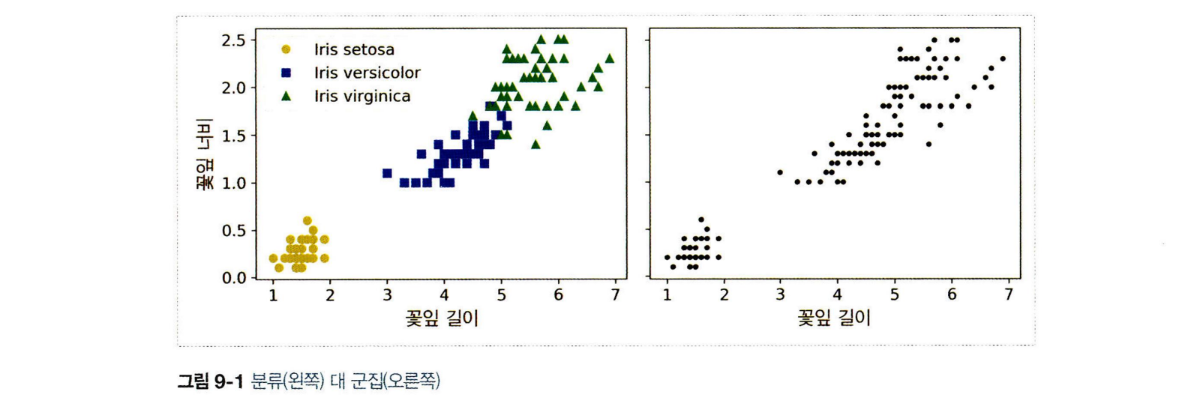

    - 왼: 레이블 있음, 분류
    - 오: 레이블 없음, 군집

**군집이 사용되는 애플리케이션**
- 고객 분류
- 데이터 분석
- 차원 축소 기법
- 이상치 탐지
- 준지도 학습
- 검색 엔진
- 이미지 분할

**클러스터**
- 명확한 정의는 없으며, 사용 알고리즘에 따라 바뀜
- 종류
 - 센트로이드라 불리는 특정 포인트를 중심으로 모인 샘플을 찾음
 - 샘플이 밀집되어 연속된 영역을 찾음
 - 계층적으로 클러스터의 클러스터를 찾음
 - etc...

*이제 군집 알고리즘인 k-평균과 DBSCAN을 살펴보고, 비선형 차원 축소&준지도 학습&이상치 탐지 애플리케이션을 알아보자!*

## 9.1.1 k-평균

**k-평균**
- 반복 몇 번으로 덩어리가 잘 보이는 데이터셋을 빠르게 클러스트로 묶음
- 각 클러스터의 중심을 찾고 가장 가까운 클러스터에 샘플을 할당함

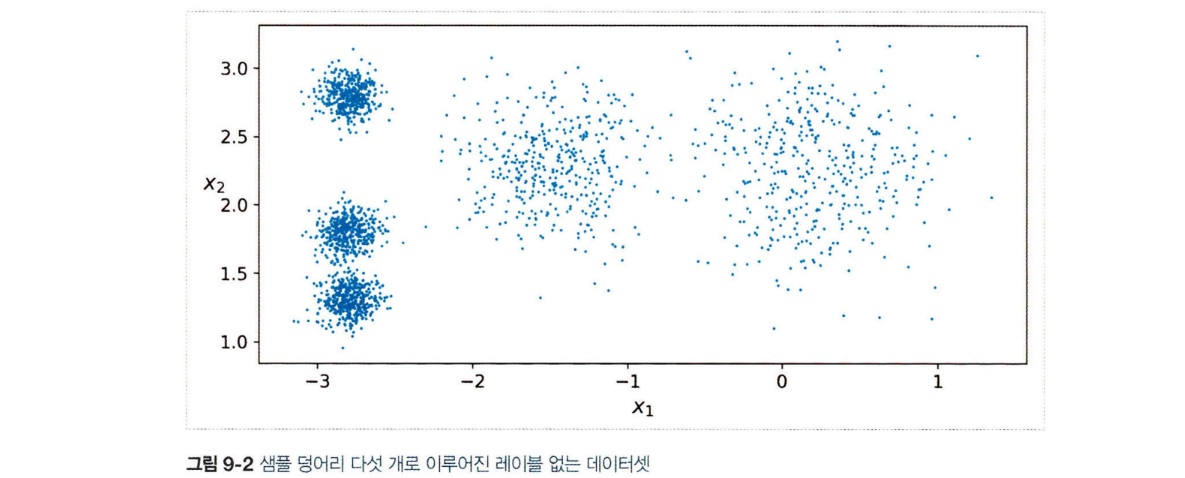

In [3]:
import warnings
warnings.filterwarnings('ignore')

# import package

import numpy as np
import os

#5장에서 소개한 moons dataset 불러오기

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X,y = make_moons(n_samples=100, noise=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
# k-평균 알고리즘 훈련

from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=k)
y_pred = kmeans.fit_predict(X)

- k: 알고리즘이 찾을 클러스터 개수
- 각 샘플은 다섯 개의 클러스터 중 하나에 할당됨
- 군집(비지도 학습)에서 각 샘플의 레이블 = 알고리즘이 할당해준 인덱스
 - 분류(지도 학습)의 클래스 레이블과 혼동x

In [5]:
y_pred

array([4, 3, 3, 4, 2, 1, 4, 3, 0, 1, 1, 4, 0, 0, 0, 4, 1, 0, 3, 3, 2, 4,
       2, 3, 1, 1, 0, 0, 1, 0, 3, 1, 0, 3, 0, 1, 3, 3, 1, 4, 1, 2, 0, 0,
       1, 3, 2, 1, 3, 1, 1, 2, 0, 2, 1, 4, 0, 2, 0, 1, 1, 3, 3, 0, 2, 0,
       2, 3, 3, 0, 0, 2, 1, 1, 0, 1, 0, 1, 0, 3, 2, 1, 4, 1, 0, 1, 1, 1,
       0, 0, 4, 1, 4, 2, 2, 2, 1, 4, 2, 0], dtype=int32)

In [6]:
y_pred is kmeans.labels_

True

In [7]:
# 이 알고리즘이 찾은 센트로이드 다섯 개

kmeans.cluster_centers_

array([[ 0.45931272, -0.08869086],
       [ 1.58367119, -0.16605306],
       [-0.28636921,  0.8943255 ],
       [ 0.53549574,  0.83683412],
       [-0.9520677 ,  0.33032694]])

In [8]:
# 새로운 샘플에 가장 가까운 센트로이드의 클러스터 할당

X_new = np.array([[0,2], [3,2], [-3,3], [-3,2.5]])
kmeans.predict(X_new)

array([2, 1, 4, 4], dtype=int32)

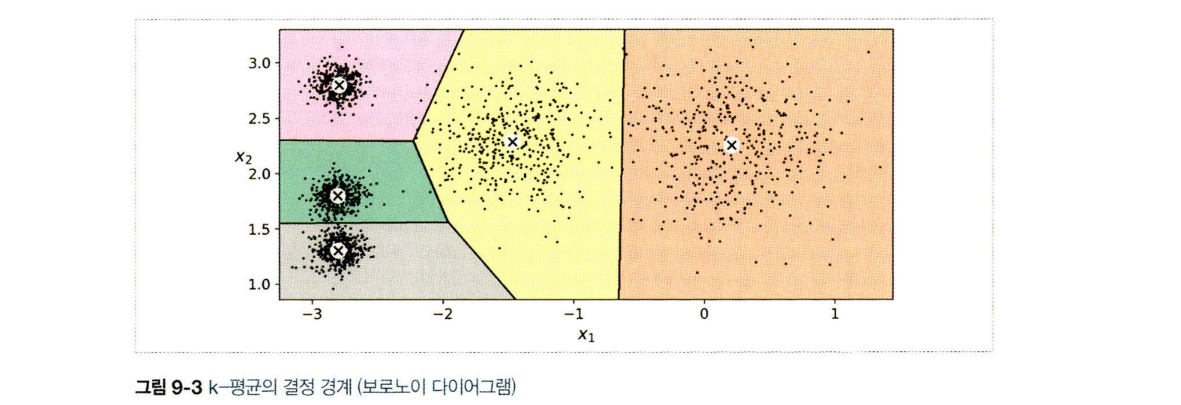

    - 샘플 몇개는 레이블이 잘못 부여됨
    - k-평균은 클러스터의 크기가 많이 다르면 잘 작동x

**소프트 군집**
- 클러스터마다 샘플에 점수 부여
- 이 점수는 샘플과 샌트로이드 사이의 거리 or 유사도 점수가 될 수 있음

In [9]:
# KMeans 클래스의 transform()메서드는 샘플과 센트로이드 사이의 거리를 반환

kmeans.transform(X_new)

array([[2.13859713, 2.68324436, 1.14215735, 1.28051183, 1.92204085],
       [3.28903046, 2.58800563, 3.46738211, 2.72520387, 4.29029687],
       [4.63754846, 5.57081085, 3.43477178, 4.14475774, 3.36469627],
       [4.32066717, 5.30262959, 3.15309097, 3.90715381, 2.98353949]])

- X_new에 있는 첫번째 샘플이 첫번째 센트로이드에서 2.53, 두번째 센트로이드에서 1.61 ... 떨어져 있음

**k-평균 알고리즘**
- 센트로이드가 주어졌을 때
 - 모든 샘플에 가장 가까운 센트로이드의 클러스터 할당
- 레이블이 주어졌을 때
 - 각 클러스터에 속한 샘플의 평균 계산하여 센트로이드 구함
- **둘 다 주어지지 않았을 때**
 1. 센트로이드를 랜덤하게 설정
 2. 샘플에 레이블을 할당하고 센트로이드 업데이트
 3. 센트로이드에 변화가 없을 때까지 반복

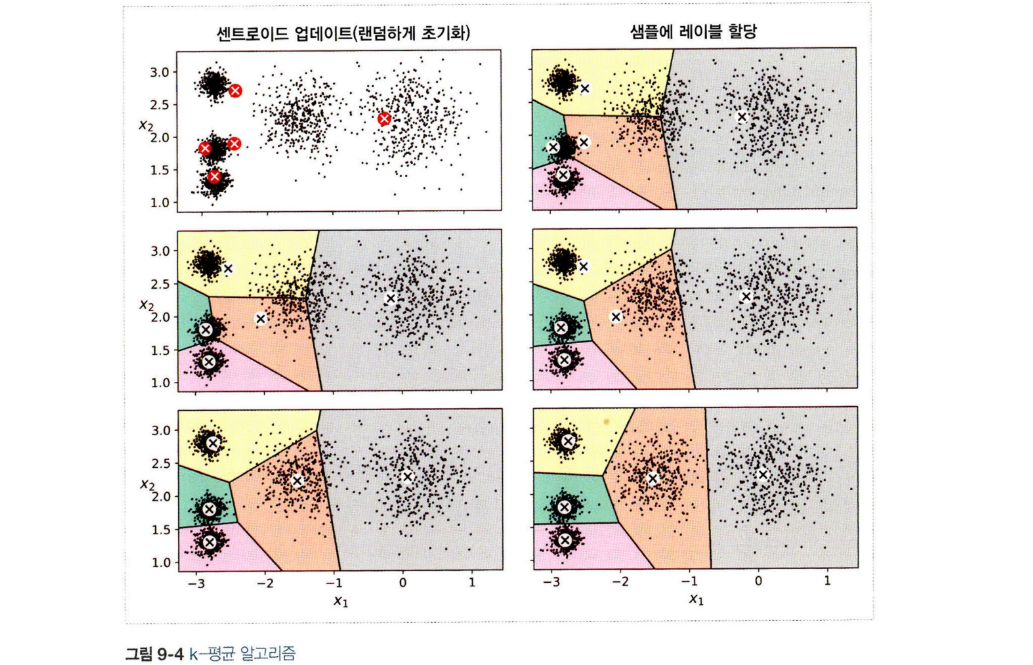

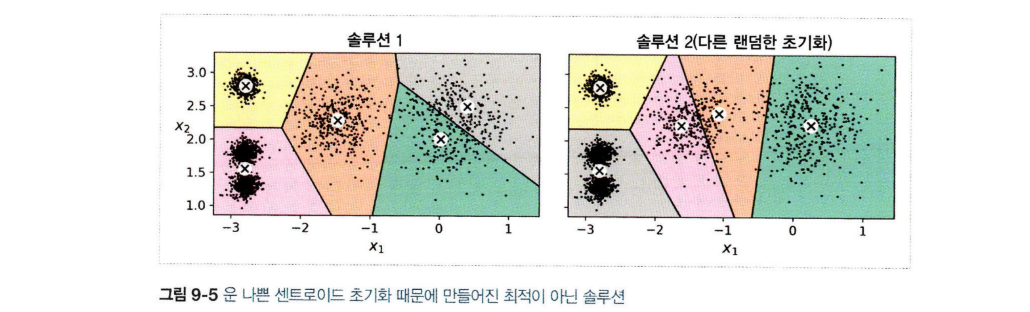

    -> 센트로이드 랜덤 초기화 단계에 운이 없으면, 알고리즘이 최적이 아닌 솔루션에 수렴할 수 있다.
    => 센트로이드 초기화를 개선하여 해결 가능

**센트로이드 초기화 방법**
- init 매개변수에 센트로이드 리스트를 담은 넘파이 배열을 지정 후 n_init을 1로 설정
- 랜덤 초기화를 다르게 하여 여러 번 알고리즘을 실행하고 가장 좋은 솔루션 선택
 - init 매개변수: 랜덤 초기화 횟수, 디폴트10
 - 이너셔: 각 샘플과 가장 가까운 센트로이드 사이의 평균 제곱 거리, 최선의 솔루션을 찾는 성능 지표

In [10]:
# init 매개변수 활용

good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)

In [11]:
# 랜덤 초기화를 다르게 - 이너셔가 가장 낮은 모델 반환

y_pred = kmeans.fit_predict(X)
kmeans.inertia_

15.884150698023277

In [12]:
# score() 메서드 - 이너셔의 음숫값을 반환(사이킷런에선 큰 값이 좋아야 해서)

kmeans.score(X)

-15.884150698023277

**k-평균++ 알고리즘**
- 다른 센트로이드와 거리가 먼 센트로이드를 선택하는 초기화 단계
- 최적이 아닌 솔루션으로 수렴할 가능성을 크게 낮춤
- KMeans 클래스는 기본적을 이 초기화 방법을 사용함
 - 원래 방식(k개 선택)을 사용하고 싶다면 **init = "random"** 지정

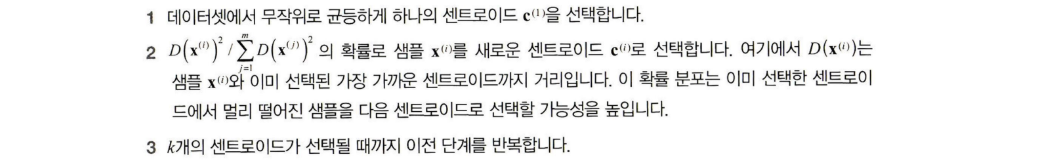

**k-평균 속도 개선과 미니배치 k-평균**
- **k-평균 속도 개선**
 - **삼각 부등식**: 두 점 사이의 직선은 항상 최단거리
 - 알고리즘의 속도를 높임
 - 샘플과 센트로이드 사이 거리를 위한 하한선과 상한선 유지
 - 원래 알고리즘 사용: **algorithm = "full"** 지정

- **미니배치 k-평균**
 - 전체 데이터셋을 사용하지 않고 각 반복마다 미니배치를 사용해 센트로이드를 조금씩 이동
 - 알고리즘의 속도를 3배에서 4배 높임
 - 대량의 데이터셋에 군집 알고리즘을 적용할 수 있음

In [13]:
# 미니배치

from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5)

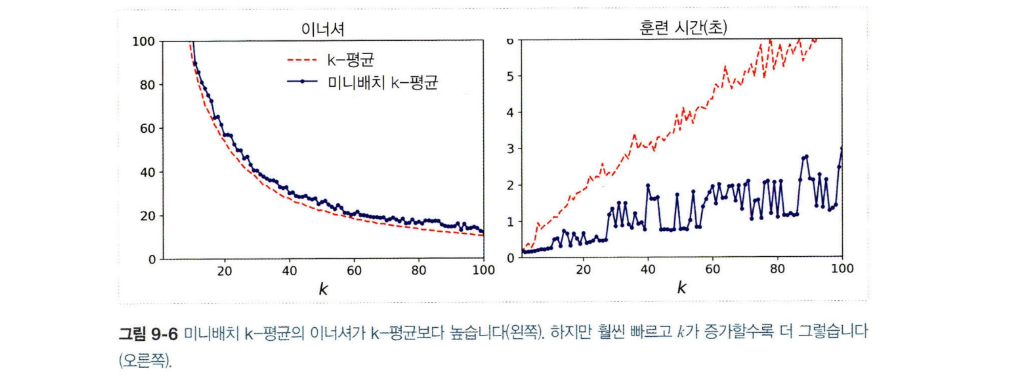

    - 미니배치 k-평균이 일반 k-평균보다 훨씬 빠르지만 이너셔는 조금 더 나쁨 (특히 클러스터가 증가할 때)
    - 왼쪽 그래프: 미니배치의 이너셔가 더 높음(안좋음)
    - 오른쪽 그래프: 미니배치의 속도가 더 빠름(좋음)

**최적의 클러스터 개수 찾기**

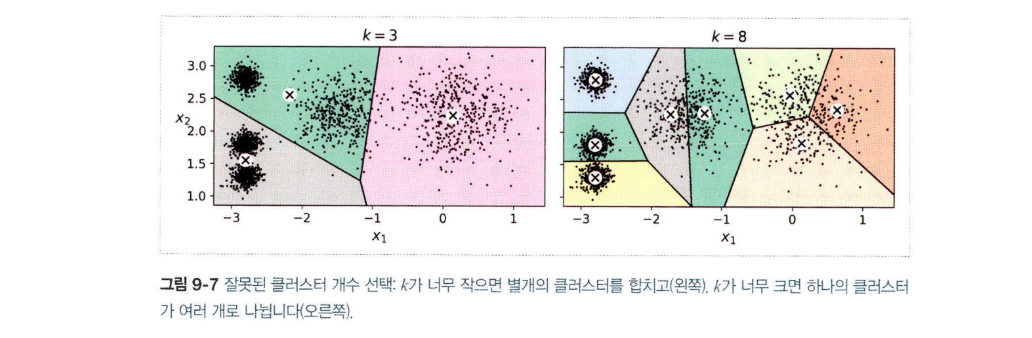

    - k를 3이나 8로 지정하면 나쁜 모델이 만들어짐

**이너셔가 작은걸 선택하면 된다?**
- 아님
- k가 커질수록 이너셔는 점점 작아지기 때문에, 클러스터 수 k 선택할 때 좋은 성능 지표가 아님

**방법1. 엘보(elbow)**

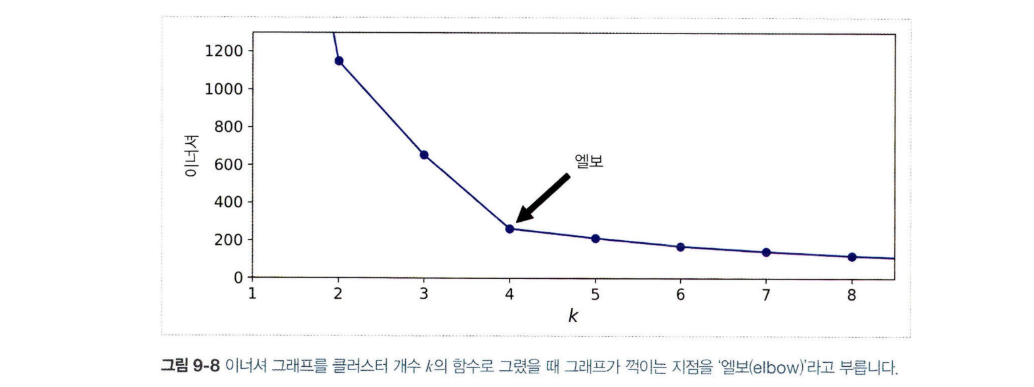

    - k가 4까지 증가할 때 이너셔가 빠르게 감소함
    - k가 더 증가하면 이너셔는 훨씬 느리게 감소함
    - k=4 가 좋은 선택 (작은 값은 변화가 심하고 큰 값은 도움이 안됨)

**방법2. 실루엣 점수**
- 엘보보다 더 정확함
- 모든 샘플에 대한 실루엣 계수의 평균
 - 샘플의 실루엣 계수(-1 ~ 1): (b-a)/max(a,b)
    - a: 클러스터 내부의 평균 거리
    - b: 가장 가까운 클러스터까지 평균 거리
 - 실루엣 계수가 +1에 가까우면 잘 속해있음
 - 실루엣 계수가 0에 가까우면 클러스터 경계에 위치한다는 의미
 - 실루엣 계수가 -1에 가까우면 이 샘플이 잘못된 클러스터에 할당되었다는 의미

In [14]:
# 실루엣 점수 계산

from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.410255013712567)

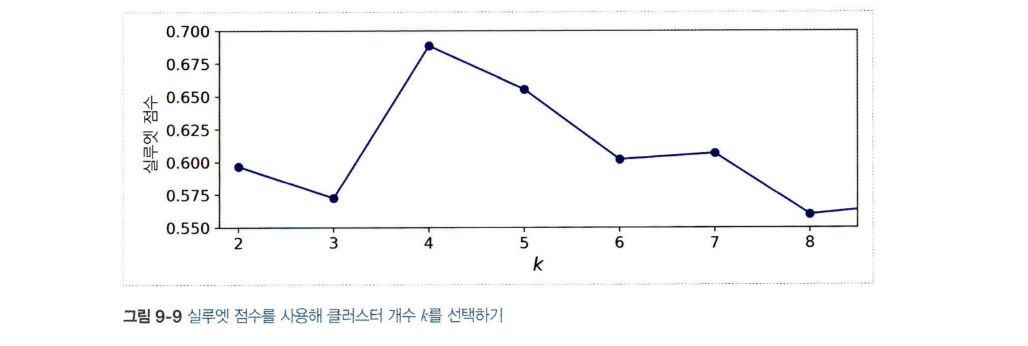

    - k=4 가 좋은 선택인 건 그대로
    - k=5 도 꽤 좋다는 사실을 알 수 있음
    - 특히 6이나 7보다 훨씬 좋음

**실루엣 다이어그램**
- 모든 샘플의 실루엣 계수를 할당된 클러스터와 계숫값으로 정렬하여 그림 -> 더 많은 정보를 얻을 수 있음

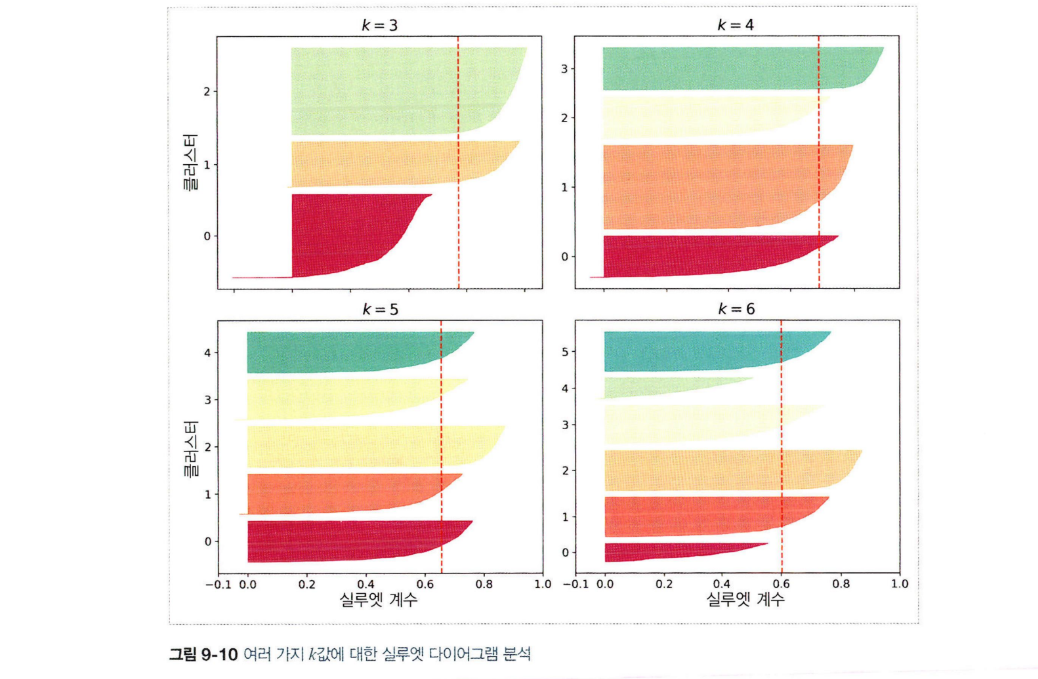

    - 그래프의 높이: 클러스터가 포함하고 있는 샘플의 개수
    - 너비: 클러스터에 포함된 샘플의 정렬된 실루엣 계수(넓을수록 Good)

- 수직 파선: 각 클러스터 개수에 해당하는 실루엣 점수
 - 많은 샘플이 파선의 왼쪽에서 멈추면 클러스터의 샘플이 다른 클러스터와 가까움(Bad)
    - ex. k=3, k=6
 - 대부분의 샘플이 파선을 넘어서 있고 1.0에 근접하면 Good
    - ex. k=4, k=5
    - k=4일 때보다 비슷한 크기의 클러스터를 얻는 k=5 선택이 더 좋음

## 9.1.2 k-평균의 한계

**k-평균의 장점**
- 속도가 빠르고 확장이 용이함

**k-평균의 단점**
- 최적이 아닌 솔루션을 피하려면 알고리즘을 여러 번 실행해야 함
- 클러스터의 개수를 지정해야 함
- 클러스터의 크기나 밀집도가 서로 다르거나 원형이 아닐 경우 잘 작동하지 않음

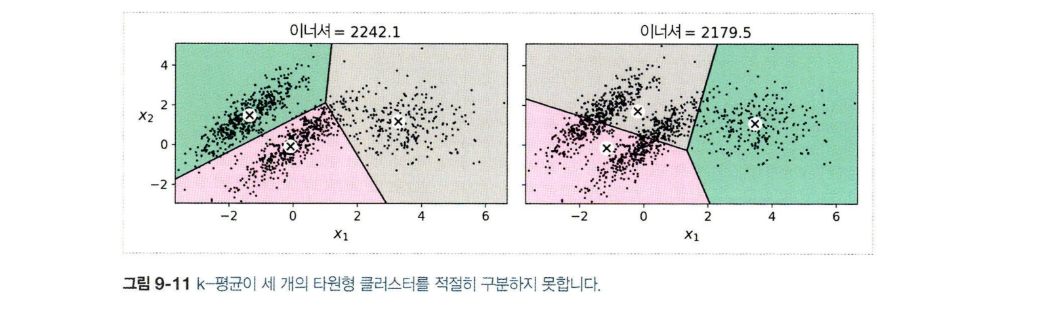

**가우시안 혼합 모델**
- 위 그림처럼 타원형 클러스터에서는 k-평균보다 가우시안 혼합 모델이 더 잘 작동함

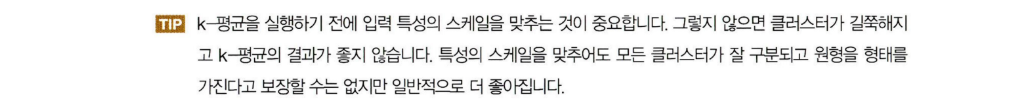

## 9.1.3 군집을 사용한 이미지 분할

**군집에서 도움을 받을 수 있는 방법들**
- 이미지 분할
 - 이미지를 세그먼트 여러개로 분할하는 작업
- 시맨틱 분할
 - 동일한 종류에 속한 모든 픽셀은 같은 세그먼트에 할당
- 색상 분할
 - 동일한 색상을 가진 픽셀을 같은 시그먼트에 할당

In [18]:
# 이미지 읽기

from matplotlib.image import imread # or `from imageio import imread`
import matplotlib.pyplot as plt

image = plt.imread("ladybug.png")
image.shape

(533, 800, 3)

- 533: 차원의 크기
- 800: 너비
- 3: 컬러 채널 개수(RGB)

In [19]:
# 이 배열을 RGB색상의 리스트로 변환 후, k-평균을 사용해 클러스터로 모음


X = image.reshape(-1,3)
kmeans = KMeans(n_clusters=8).fit(X)
segmented_image = kmeans.cluster_centers_[kmeans.labels_]
segmented_image = segmented_image.reshape(image.shape)

- ex. 모든 초록색을 하나의 컬러 클러스터로 만듦
- 각 색상에 대해 그 픽셀의 클러스터의 평균 컬러를 찾음
- 그 평균 색으로 모든 초록색을 바꿈
- 긴 색상의 리스트를 원본 이미지와 동일한 크기로 바꿈

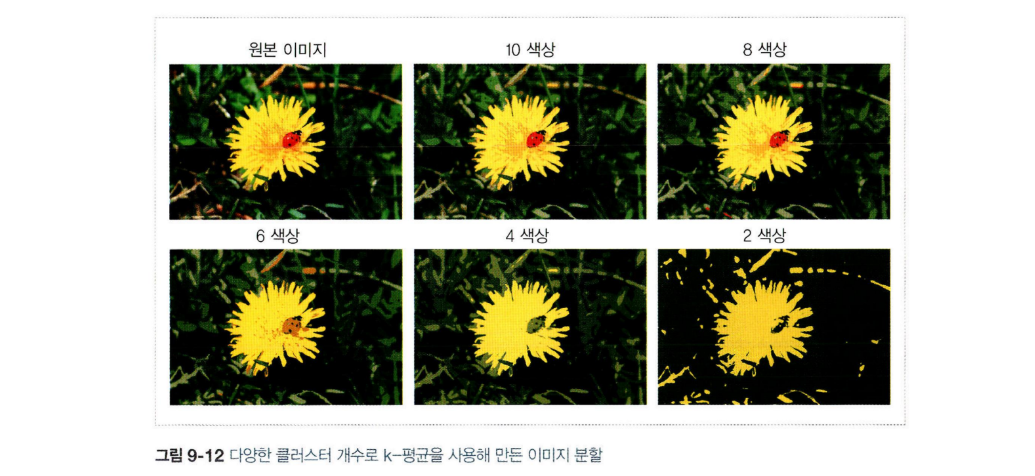

    - 8개보다 클러스터 수를 적게 하면 빨간색이 독자적인 클러스터를 만들지 못하고 주위 색에 합쳐짐
     - k-평균이 비슷한 크기의 클러스터를 만들지 못하고 주위 색에 합쳐짐

## 9.1.4 군집을 사용한 전처리

- 군집: 차원 축소에 효과적
 - 지도 학습 알고리즘 적용 전, 전처리 단계로 사용할 수 있음

In [20]:
# 숫자 데이터 불러오기

from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)

In [21]:
# 훈련, 테스트셋 나누기

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)

In [22]:
# 로지스틱 회귀 모델 훈련

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [23]:
# 정확도 평가

log_reg.score(X_test, y_test)

0.9666666666666667

- 숫자 데이터셋에서 훈련/테스트를 나눠 로지스틱 회귀 모델을 훈련시킨 결과, 0.97의 정확도가 나옴
- k-평균으로 전처리해서 정확도가 오르는지 확인해보자!

In [24]:
# 파이프라인을 만들어 훈련 세트를 50개의 클러스터로 모으고, 이미지를 50개 클러스터까지 거리로 바꿈
# 그리고 로지스틱 회귀 적용

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50)),
    ("log_reg", LogisticRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                ('log_reg', LogisticRegression())])

In [25]:
# 분류 파이프라인 평가

pipeline.score(X_test, y_test)

0.9533333333333334

- 전처리를 통해 정확도가 조금 더 높아짐

In [26]:
# 교차 검증으로 가장 좋은 분류 성능을 내는 k값 찾아보기

from sklearn.model_selection import GridSearchCV

param_grid = dict(kmeans__n_clusters=range(2, 100))
grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.2s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=5; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=5; total time=   0.1s
[CV] END ...............................kmeans_

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                                       ('log_reg', LogisticRegression())]),
             param_grid={'kmeans__n_clusters': range(2, 100)}, verbose=2)

In [27]:
# 최선의 k값과 성능을 확인

grid_clf.best_params_

{'kmeans__n_clusters': 95}

In [28]:
grid_clf.score(X_test, y_test)

0.9577777777777777

- k=70개의 클러스터를 사용할 떄 정확도기 크게 향상됨

## 9.1.5 군집을 사용한 준지도 학습

- 레이블이 없는 데이터가 많고 레이블있는 데이터 적을 때 사용

In [29]:
# 레이블된 50개 샘플에 로지스틱 회귀 모델 훈련

n_labeled = 50
log_reg = LogisticRegression()
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression()

In [30]:
# 테스트셋에서 이 모델의 성능

log_reg.score(X_test, y_test)

0.8288888888888889

- 전체 데이터셋을 사용했을 때보다 정확도가 낮음
- 해결해보자

In [31]:
# 훈련 세트를 50개의 클러스터로 모으고, 각 클러스터에서 가장 가까운 이미지를 찾음(대표 이미지)

k = 50
kmeans = KMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

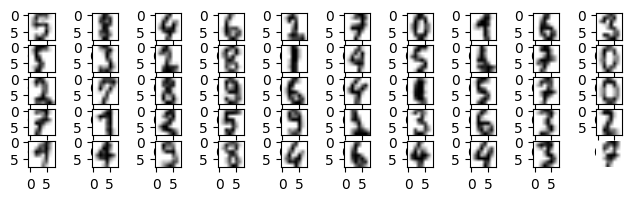

In [32]:
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary", interpolation="bilinear")

plt.axis('off')
plt.show()

In [49]:
# 이미지 보고 수동으로 할당

y_representative_digits = np.array([5, 8, 4, 6, 2, 7, 0, 1, 6, 3,
                                    5, 3, 2, 8, 1, 4, 5, 1, 7, 0,
                                    2, 7, 8, 9, 6, 4, 4, 5, 7, 0,
                                    7, 1, 2, 5, 9, 2, 3, 6, 3, 2,
                                    9, 4, 9, 8, 4, 6, 4, 4, 3, 7])

In [50]:
log_reg = LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.9

- 비용이 많이 들고 어려움
- 무작위 샘플 대신 대표 샘플에 레이블 할당 가능
 - 레이블 전파: 이 레이블을 동일한 클러스터에 있는 모든 샘플에 전파함

---

In [51]:
# 레이블 전파

y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [52]:
# 모델 재훈련 후 성능 확인

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.9222222222222223

In [53]:
# 센트로이드와 가까운 샘플의 20%에만 레이블 전파

percentile_closest = 20

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [54]:
# 모델 재훈련

log_reg = LogisticRegression()
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.9133333333333333

In [55]:
np.mean(y_train_partially_propagated == y_train[partially_propagated])

np.float64(0.9547038327526133)

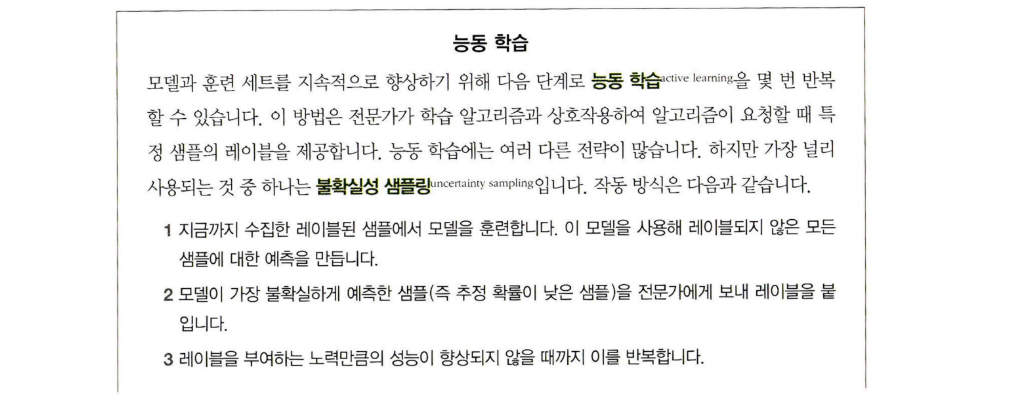

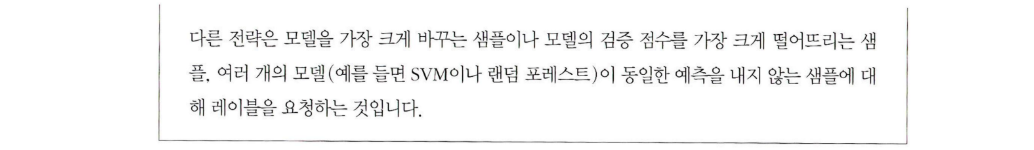

## 9.1.6 DBSCAN

- 밀집된 연속적 지역을 클러스터로 정의함
- 모든 클러스터가 충분히 밀집되어 있고 밀집되지 않은 지역과 잘 구분될 때 성능 굿

**작동 방식**

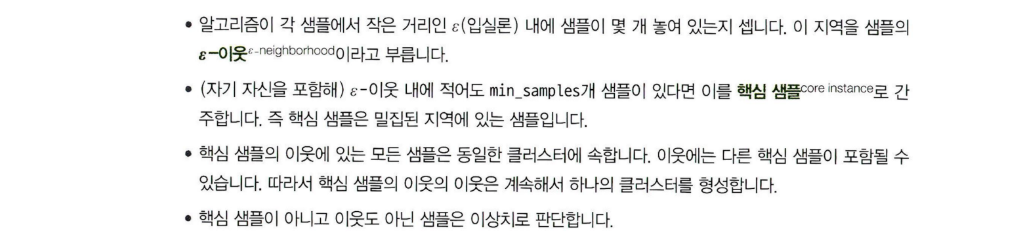

In [56]:
# 반달 모양 데이터셋에서 DBSCAN 클래스 사용

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [57]:
# 모든 샘플의 레이블은 인스턴스 변수 labels_에 저장되어 있음

dbscan.labels_

array([ 0,  2,  0,  3,  1,  2,  3,  0,  2,  3,  0,  2,  3,  0,  4,  3,  3,
        2,  2,  3,  0,  2,  0,  4,  0, -1,  3,  3,  3,  3,  3, -1,  3,  0,
        3,  3,  0,  3,  3,  3,  0,  2, -1,  3,  2,  0,  2,  3,  2,  2,  3,
       -1,  3,  0,  3,  3,  3,  2,  3,  3,  3,  3,  2,  3,  2,  3,  3,  3,
        2,  2,  0,  3, -1,  3,  3,  3,  3,  3,  3,  0,  2,  3,  3,  0,  2,
        2,  2,  3,  2,  3,  3,  3,  4,  3,  3,  2,  3,  2,  0,  2,  0,  3,
        3,  3,  3,  3,  3,  0,  2,  2,  2,  3,  3,  2,  3,  2,  3,  3,  3,
        3,  2,  5,  2,  2,  0,  4,  2,  2,  0, -1,  2,  4, -1,  3,  0,  2,
        2,  0,  3,  3, -1,  3,  3, -1,  3,  3,  1, -1,  3,  3,  3,  3,  3,
        3,  2,  0,  2,  3,  2,  3,  3,  3,  3,  0,  3,  2,  3,  4, -1,  2,
        3,  0,  3,  2,  3, -1,  3,  3,  3,  3,  0,  3,  3,  2, -1,  4, -1,
        0,  3,  3,  2,  2, -1,  3,  2,  4,  0,  0,  2,  2,  3,  0,  2,  3,
        2, -1,  2,  0,  2,  0,  3,  2,  3,  3,  3,  2,  0,  3,  3,  3,  2,
        3,  3,  3,  0,  3

- 일부 샘플의 클러스터 인덱스: -1
 - 이상치로 판단되었다는 의미

In [58]:
# 핵심 샘플의 인덱스는 인스턴스 변수 core_sample_indices_에 저장

len(dbscan.core_sample_indices_)

801

In [59]:
dbscan.core_sample_indices_

array([  0,   2,   4,   5,   6,   7,   8,   9,  11,  12,  13,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  26,  27,  28,  29,
        30,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  43,  44,
        46,  47,  48,  49,  50,  52,  53,  54,  55,  56,  57,  58,  59,
        60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  82,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 122, 123, 124, 126, 130, 133, 134, 135,
       136, 138, 139, 141, 142, 144, 145, 146, 149, 150, 151, 152, 153,
       154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166, 167,
       169, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 181, 182,
       185, 187, 188, 189, 190, 191, 193, 194, 195, 196, 198, 199, 200,
       201, 202, 203, 206, 207, 208, 209, 210, 211, 212, 213, 21

In [60]:
# 핵심 샘플 자체는 인스턴스 변수 components_에 저장

dbscan.components_

array([[-0.66315474,  0.76273778],
       [-0.93134015,  0.08057919],
       [-0.05192362,  0.44342256],
       ...,
       [-0.90811002,  0.3907233 ],
       [ 0.47928931, -0.31352275],
       [ 2.00854618,  0.37019125]])

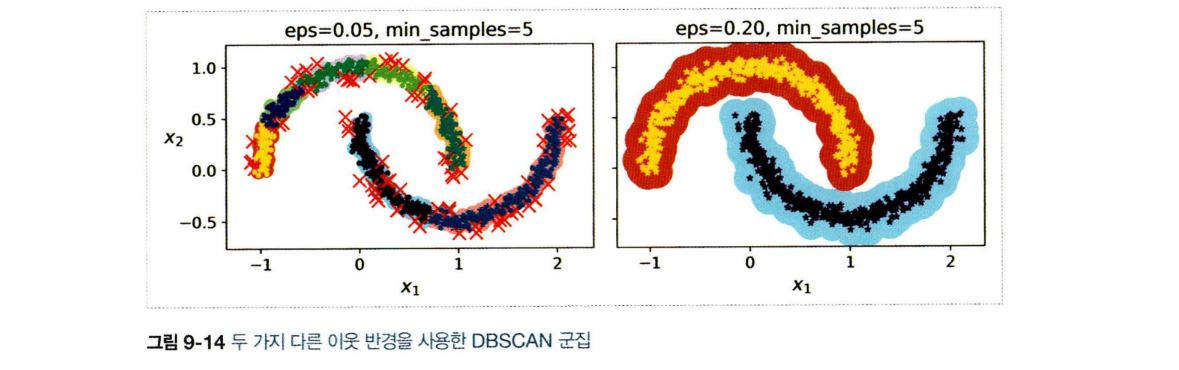

- DBSCAN 클래스는 predict() 메서드 대신 fit_predict() 메서드 제공
 - 새로운 샘플에 대해 클러스터를 예측 불가
 - 사용자가 필요한 예측기를 선택해야 함

In [61]:
# KNeighborsClassifier 훈련해보기

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [62]:
# 샘플 몇개의 클러스터 예측

X_new = np.array([ [-0.5, 0], [0, 0.5], [1, -0.1], [2, 1] ])
knn.predict(X_new)

array([0, 3, 2, 3])

In [63]:
# 샘플의 확률 추정

knn.predict_proba(X_new)

array([[0.76, 0.  , 0.  , 0.24, 0.  , 0.  ],
       [0.  , 0.26, 0.04, 0.56, 0.  , 0.14],
       [0.  , 0.  , 0.54, 0.46, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 1.  , 0.  , 0.  ]])

- 핵심 샘플 훈련 / 모든 샘플 훈련 / 이상치 제거 등 성능에 따라 결정 가능

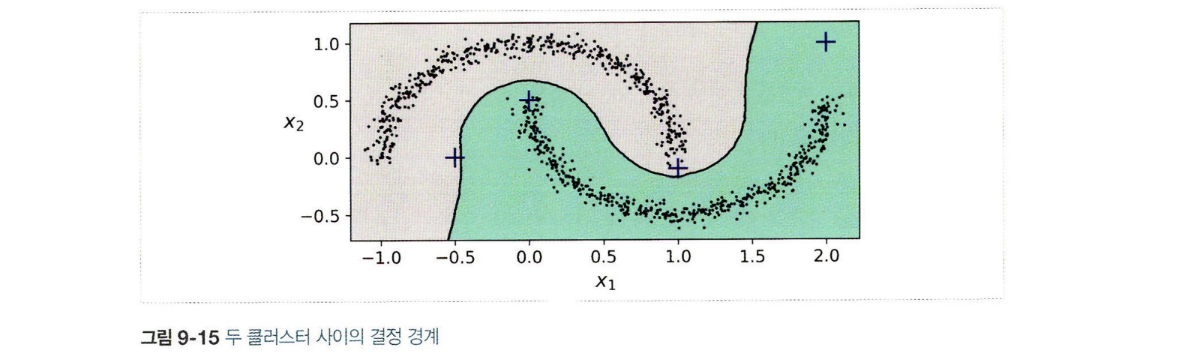

In [64]:
# kneighbors() 메서드를 사용
# 샘플을 전달해 훈련 세트에서 가장 가까운 k개 이웃의 거리와 인덱스 반환
# 즉, 열을 k개 가진 행렬 두 개를 반환

y_dist, y_pred_idk = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idk]
y_pred[y_dist>0.2] = -1
y_pred.ravel()

array([-1,  1,  2, -1])

**DBSCAN**
- 클러스터의 모양, 개수에 상관없이 감지 가능
- 이상치에 안정적
- 하이퍼 파라미터 두 개
 - eps
 - min_samples
- 클러스터간의 밀집도가 다르면 정확성이 떨어짐

## 9.1.7 다른 군집 알고리즘

**병합 군집**
- 클러스터 계층을 밑바닥부터 쌓아 구성
- 처음에는 샘플 하나에서 시작

**BIRCH**
- 대규모 데이터셋을 위해 고안됨
- 특성 수가 20개 이하일 땐 배치 k-평균보다 빠르고 비슷한 결과
- 트리에 모든 정보를 저장하지 않아 대용량 데이터셋도 다룰 수 있음

**평균-이동**
- 각 샘플을 중심으로 하는 원을 그림
- 원마다 안에 포함된 모든 샘플의 평균을 구함
- 원의 중심을 평균점으로 이동시킴
- 원이 움직이지 않을 때까지 반복
- DBSCAN과 유사한 점
 - 모양, 개수 상관X
 - 하이퍼파라미터 적음(bandwidth 하나)
 - 국부적인 밀집도 추정에 의존
- 밀집도가 불균형할 때 여러 개로 나눔
- 대규모엔 적합하지 X

**유사도 전파**
- 투표 방식 사용
- 샘플은 자신을 대표할 수 있는 비슷한 샘플에 투표
- 대규모 적합하지 X

**스펙트럼 군집**
- 샘플 사이의 유사도 행렬을 받아 저차원 임베딩을 만듦(차원을 축소함)
- 저차원 공간에서 또다른 군집 알고리즘 사용
- 샘플 개수가 많거나 클러스터 크기가 다르면 잘 동작하지 X